# Bounding Box Review

Review and filter detections per panel **before** running `extract_crops.py`.

**Workflow:**
1. Pick a panel from the dropdown  
2. Adjust the containment threshold — sub-crops (bboxes mostly inside a larger one) are auto-excluded (red)  
3. Toggle individual detections in the card grid to manually include/exclude  
4. Click **Save approved** — writes `annotated/<panel>_approved.json` (same schema, excluded detections removed)  
5. Run `extract_crops.py --approved-dir` to crop only approved detections

Approved files accumulate — you can review panels in any order.

In [4]:
# ── Cell 1: imports & paths ────────────────────────────────────────────────
import json
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image

REPO_ROOT    = Path("../..")
ANNOTATED    = REPO_ROOT / "frobenius_artifacts/analysis/annotated"
PANELS_DIR   = REPO_ROOT / "frobenius_artifacts/analysis/panels"

# Collect all panels that have both a detections JSON and a panel PNG
_jsons = sorted(ANNOTATED.glob("*_detections.json"))
_panels = []
for j in _jsons:
    stem = j.stem.replace("_detections", "")
    png  = PANELS_DIR / f"{stem}.png"
    if png.exists():
        _panels.append((stem, j, png))
    else:
        # try _cropped suffix variant
        alt = PANELS_DIR / f"{stem}_cropped.png"
        if alt.exists():
            _panels.append((stem, j, alt))

print(f"{len(_panels)} panels with both detections JSON and panel PNG")
for stem, j, png in _panels[:5]:
    dets = json.loads(j.read_text())
    print(f"  {stem}: {len(dets)} detections")

57 panels with both detections JSON and panel PNG
  EBA-B_00425_Ibadan_q97912_i1_panel_00: 3 detections
  EBA-B_00642_q98212_i3_panel_00: 8 detections
  EBA-Div_00302_q166558_i1_panel_00: 3 detections
  EBA-Div_00303_Ado_Ekiti_q166559_i1_panel_00: 1 detections
  EBA-Div_00311_Ife_q166566_i1_panel_00: 6 detections


HTML(value="<h3 style='margin:4px 0'>Bounding Box Review</h3>")

Dropdown(description='Panel:', layout=Layout(width='90%'), options=(('EBA-B_00425_Ibadan_q97912_i1_panel_00', …

HTML(value="<div style='font-size:11px;color:#999;margin:2px 0 4px 0'><b>sub-crop filter</b>: higher = stricte…

Output()

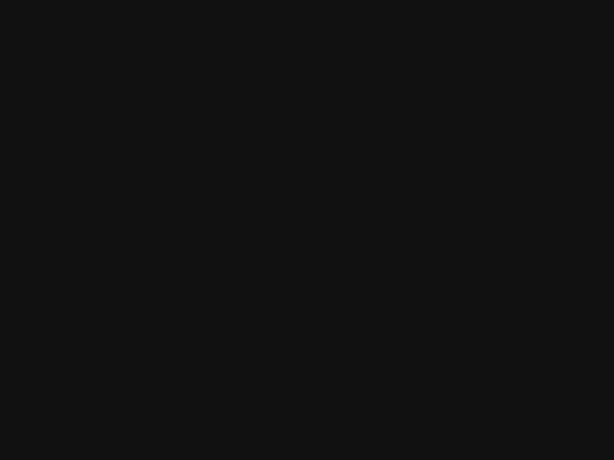

HTML(value="<b style='font-size:13px'>Detection cards — toggle to include/exclude</b>")

Output()

HTML(value="<b style='font-size:13px;color:#ffcc00'>Candidate pool (SAM masks below filter threshold)</b>")

Output()

In [5]:
%matplotlib widget
## ── Cell 2: main review UI ─────────────────────────────────────────────────
#
# Controls:
#   Panel dropdown       — pick a panel to review
#   [D] Draw bbox        — toggle drag-to-draw mode; click+drag on image draws bbox
#   Sliders x/y/w/h      — fine-tune after drawing; cyan preview updates live
#   [Add bbox ✓]         — commit the pending bbox as source="manual"
#   Sub-crop filter      — exclude small bboxes mostly inside a larger one
#   Min SAM quality      — hide detections below this SAM confidence score
#   Detection cards      — toggle include/exclude per detection
#   [Show candidates]    — overlay SAM masks below threshold as dashed yellow
#   [SAM Refine]         — probe uncovered areas with SamPredictor; uses cross-panel
#                          bbox sizes to inform what scale of motif to look for
#   [Revert to saved]    — discard unsaved changes, reload from _approved.json
#   Save approved        — writes <panel>_approved.json with source field

import io as _io

# ── Helpers ───────────────────────────────────────────────────────────────────
def _containment(a, b):
    ax1, ay1 = a["x"], a["y"];  ax2, ay2 = ax1 + a["w"], ay1 + a["h"]
    bx1, by1 = b["x"], b["y"];  bx2, by2 = bx1 + b["w"], by1 + b["h"]
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    if ix2 <= ix1 or iy2 <= iy1: return 0.0
    inter = (ix2 - ix1) * (iy2 - iy1)
    min_area = min(a["w"] * a["h"], b["w"] * b["h"])
    return inter / min_area if min_area > 0 else 0.0

def _iou_bbox(a, b):
    ax1, ay1 = a["x"], a["y"];  ax2, ay2 = ax1 + a["w"], ay1 + a["h"]
    bx1, by1 = b["x"], b["y"];  bx2, by2 = bx1 + b["w"], by1 + b["h"]
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    if ix2 <= ix1 or iy2 <= iy1: return 0.0
    inter = (ix2 - ix1) * (iy2 - iy1)
    union = a["w"] * a["h"] + b["w"] * b["h"] - inter
    return inter / union if union > 0 else 0.0

def _auto_exclude(dets, threshold):
    n = len(dets)
    areas = [d["bbox"]["w"] * d["bbox"]["h"] for d in dets]
    by_size = sorted(range(n), key=lambda i: -areas[i])
    suppress = set()
    for pos, i in enumerate(by_size):
        if i in suppress: continue
        for j in by_size[pos + 1:]:
            if j not in suppress and _containment(dets[i]["bbox"], dets[j]["bbox"]) >= threshold:
                suppress.add(j)
    return suppress

def _thumb(panel_img, bbox, size=96, bg=(30, 30, 30)):
    iw, ih = panel_img.size
    b = bbox
    crop = panel_img.crop((max(0, b["x"]), max(0, b["y"]),
                           min(iw, b["x"] + b["w"]), min(ih, b["y"] + b["h"])))
    crop.thumbnail((size, size))
    sq = Image.new("RGB", (size, size), bg)
    sq.paste(crop, ((size - crop.width) // 2, (size - crop.height) // 2))
    buf = _io.BytesIO();  sq.save(buf, format="PNG")
    return widgets.Image(value=buf.getvalue(), format="png", width=size, height=size)


# ── State ─────────────────────────────────────────────────────────────────────
MAX_DISPLAY_W = 900

_state = {
    "stem": None, "dets": [], "candidates": [], "panel_img": None,
    "checkboxes": [], "cand_checkboxes": [],
    "auto_excl": set(), "dirty": False, "show_candidates": False,
}
_img_cache   = {"stem": None, "arr": None, "scale": 1.0}
_drag        = {"active": False, "x0": 0, "y0": 0}
_draw_state  = {"mode_on": False}
_no_obs      = [False]


# ── Persistent figure ─────────────────────────────────────────────────────────
_fig, _ax = plt.subplots(1, 1, dpi=96,
                          gridspec_kw={"left": 0, "right": 1, "top": 1, "bottom": 0})
_fig.patch.set_facecolor("#111")
_ax.set_facecolor("#111")
_ax.axis("off")


def _fig_scale():
    if _state["panel_img"] is None: return 1.0
    return min(1.0, MAX_DISPLAY_W / _state["panel_img"].size[0])


def _update_panel_view(with_pending=False):
    if _state["panel_img"] is None: return
    import numpy as _np_local
    panel_img = _state["panel_img"]
    iw, ih = panel_img.size
    scale = min(1.0, MAX_DISPLAY_W / iw)
    dw, dh = int(iw * scale), int(ih * scale)

    _ax.clear()
    _ax.axis("off")

    if _img_cache["stem"] != _state["stem"]:
        _img_cache["arr"]   = _np_local.array(panel_img.resize((dw, dh), Image.LANCZOS))
        _img_cache["stem"]  = _state["stem"]
        _img_cache["scale"] = scale
    _ax.imshow(_img_cache["arr"])

    for i, d in enumerate(_state["dets"]):
        b = d["bbox"]
        x, y, w, h = b["x"]*scale, b["y"]*scale, b["w"]*scale, b["h"]*scale
        inc   = _state["checkboxes"][i].value if i < len(_state["checkboxes"]) else True
        color = "#44dd44" if inc else "#ff4444"
        _ax.add_patch(mpatches.Rectangle(
            (x, y), w, h,
            linewidth=2.5 if inc else 1.5,
            edgecolor=color, facecolor="none", alpha=0.9 if inc else 0.55,
        ))
        _ax.text(x+3, y+3, str(d["index"]),
                 fontsize=max(6, int(10*scale)), color=color, va="top", fontweight="bold",
                 bbox=dict(facecolor="black", alpha=0.4, pad=1, linewidth=0))

    if _state["show_candidates"] and _state["candidates"]:
        for c in _state["candidates"]:
            b = c["bbox"]
            x, y, w, h = b["x"]*scale, b["y"]*scale, b["w"]*scale, b["h"]*scale
            _ax.add_patch(mpatches.Rectangle(
                (x, y), w, h,
                linewidth=1.5, edgecolor="#ffcc00", facecolor="none",
                alpha=0.6, linestyle="dashed",
            ))
            _ax.text(x+3, y+3, f"C{c['_cand_idx']}",
                     fontsize=max(5, int(8*scale)), color="#ffcc00", va="top",
                     bbox=dict(facecolor="black", alpha=0.3, pad=1, linewidth=0))

    if with_pending:
        pb = {"x": w_mx.value, "y": w_my.value, "w": w_mw.value, "h": w_mh.value}
        if pb["w"] > 0 and pb["h"] > 0:
            x, y = pb["x"]*scale, pb["y"]*scale
            w2, h2 = pb["w"]*scale, pb["h"]*scale
            _ax.add_patch(mpatches.Rectangle(
                (x, y), w2, h2, linewidth=0, facecolor="#00ffff", alpha=0.12))
            _ax.add_patch(mpatches.Rectangle(
                (x, y), w2, h2, linewidth=2.5, edgecolor="#00ffff",
                facecolor="none", alpha=0.95, linestyle=(0, (6, 3))))
            _ax.text(x+4, y+4, "new",
                     fontsize=max(7, int(11*scale)), color="#00ffff", va="top",
                     fontweight="bold",
                     bbox=dict(facecolor="black", alpha=0.45, pad=1, linewidth=0))

    if _draw_state["mode_on"]:
        _ax.set_title("Draw mode ON — drag to select a motif region",
                       color="#00cccc", fontsize=10, pad=3)

    _fig.canvas.draw_idle()


# ── Drag-draw mouse handlers ──────────────────────────────────────────────────
def _on_mouse_press(event):
    if not _draw_state["mode_on"]: return
    if event.inaxes != _ax or event.button != 1: return
    scale = _img_cache["scale"] or _fig_scale()
    _drag["active"] = True
    _drag["x0"] = max(0, int(event.xdata / scale)) if event.xdata is not None else 0
    _drag["y0"] = max(0, int(event.ydata / scale)) if event.ydata is not None else 0

def _on_mouse_move(event):
    if not _drag["active"] or not _draw_state["mode_on"]: return
    if event.inaxes != _ax or event.xdata is None: return
    scale = _img_cache["scale"] or _fig_scale()
    x0, y0 = _drag["x0"], _drag["y0"]
    x1 = max(0, int(event.xdata / scale))
    y1 = max(0, int(event.ydata / scale))
    if _state["panel_img"]:
        pw, ph = _state["panel_img"].size
        x1 = min(x1, pw - 1); y1 = min(y1, ph - 1)
    x = min(x0, x1); y = min(y0, y1)
    w = max(1, abs(x1 - x0)); h = max(1, abs(y1 - y0))
    _no_obs[0] = True
    w_mx.value = x;  w_my.value = y
    w_mw.value = w;  w_mh.value = h
    _no_obs[0] = False
    _sync_labels()
    _update_panel_view(with_pending=True)

def _on_mouse_release(event):
    if not _drag["active"]: return
    _drag["active"] = False
    _update_panel_view(with_pending=True)

_fig.canvas.mpl_connect("button_press_event",   _on_mouse_press)
_fig.canvas.mpl_connect("motion_notify_event",  _on_mouse_move)
_fig.canvas.mpl_connect("button_release_event", _on_mouse_release)


# ── Widgets ───────────────────────────────────────────────────────────────────
_sl = dict(continuous_update=False,
           style={"description_width": "180px"},
           layout=widgets.Layout(width="60%"))

w_panel = widgets.Dropdown(
    options=[(s, i) for i, (s, _, __) in enumerate(_panels)],
    description="Panel:",
    style={"description_width": "60px"},
    layout=widgets.Layout(width="90%"),
)
w_contain = widgets.FloatSlider(min=0.0, max=1.0, step=0.05, value=0.75,
    description="sub-crop filter", readout_format=".2f", **_sl)
w_min_iou = widgets.FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0,
    description="min SAM quality", readout_format=".2f", **_sl)

btn_save       = widgets.Button(description="Save approved",   button_style="success",
                                layout=widgets.Layout(width="160px", margin="8px 0"))
btn_all_in     = widgets.Button(description="Include all",     button_style="info",
                                layout=widgets.Layout(width="110px"))
btn_all_out    = widgets.Button(description="Exclude all",     button_style="warning",
                                layout=widgets.Layout(width="110px"))
btn_reset      = widgets.Button(description="Reset to auto",   button_style="",
                                layout=widgets.Layout(width="120px"))
btn_revert     = widgets.Button(description="Revert to saved", button_style="danger",
                                layout=widgets.Layout(width="135px"),
                                tooltip="Discard all unsaved changes (including SAM Refine) "
                                        "and reload from the last saved _approved.json")
btn_candidates = widgets.Button(description="Show candidates", button_style="",
                                layout=widgets.Layout(width="145px"))
btn_draw_mode  = widgets.Button(description="[D] Draw bbox",   button_style="",
                                layout=widgets.Layout(width="130px"),
                                tooltip="Toggle: click+drag on the panel image to draw a new bbox")
btn_sam_refine = widgets.Button(description="SAM Refine",      button_style="",
                                layout=widgets.Layout(width="120px"),
                                tooltip="Probe uncovered areas with SamPredictor; "
                                        "uses approved manual bboxes as size templates")

# ── SAM Refine tuning sliders ─────────────────────────────────────────────────
_ref_sl = dict(continuous_update=False,
               style={"description_width": "130px"},
               layout=widgets.Layout(width="48%"))
w_ref_score = widgets.FloatSlider(min=0.50, max=0.99, step=0.01, value=0.85,
    description="min SAM score", readout_format=".2f", **_ref_sl)
w_ref_min_area = widgets.FloatSlider(min=0.005, max=0.20, step=0.005, value=0.01,
    description="min area %", readout_format=".1%", **_ref_sl)
w_ref_max_area = widgets.FloatSlider(min=0.10, max=0.80, step=0.05, value=0.50,
    description="max area %", readout_format=".0%", **_ref_sl)
w_ref_edge = widgets.FloatSlider(min=0.0, max=0.15, step=0.005, value=0.03,
    description="min edge density", readout_format=".1%", **_ref_sl)

refine_section = widgets.VBox([
    widgets.HTML(
        "<b style='font-size:12px;color:#dd8800'>"
        "SAM Refine settings — adjust before clicking SAM Refine:</b>"
    ),
    widgets.HBox([w_ref_score, w_ref_min_area]),
    widgets.HBox([w_ref_max_area, w_ref_edge]),
], layout=widgets.Layout(
    border="1px solid #664400", padding="6px 10px", margin="4px 0",
    background="#1a0d00",
))

# ── Precision sliders ─────────────────────────────────────────────────────────
_draw_sl = dict(
    continuous_update=True,
    style={"description_width": "18px"},
    layout=widgets.Layout(width="88%"),
)
w_mx = widgets.IntSlider(value=0,   min=0, max=2000, step=1, description="x", **_draw_sl)
w_my = widgets.IntSlider(value=0,   min=0, max=2000, step=1, description="y", **_draw_sl)
w_mw = widgets.IntSlider(value=200, min=1, max=2000, step=1, description="w", **_draw_sl)
w_mh = widgets.IntSlider(value=200, min=1, max=2000, step=1, description="h", **_draw_sl)

_lbl_mx = widgets.Label(layout=widgets.Layout(width="52px"))
_lbl_my = widgets.Label(layout=widgets.Layout(width="52px"))
_lbl_mw = widgets.Label(layout=widgets.Layout(width="52px"))
_lbl_mh = widgets.Label(layout=widgets.Layout(width="52px"))

def _sync_labels(_=None):
    _lbl_mx.value = str(w_mx.value); _lbl_my.value = str(w_my.value)
    _lbl_mw.value = str(w_mw.value); _lbl_mh.value = str(w_mh.value)

_sync_labels()

btn_add_manual = widgets.Button(description="Add bbox ✓", button_style="info",
                                layout=widgets.Layout(width="110px"))

_row_style = widgets.Layout(width="49%", align_items="center")
draw_section = widgets.VBox([
    widgets.HTML(
        "<b style='font-size:12px;color:#00cccc'>"
        "Pending bbox — drag on image to draw, or use sliders for precision:</b>"
    ),
    widgets.HBox([
        widgets.VBox([
            widgets.HBox([w_mx, _lbl_mx], layout=_row_style),
            widgets.HBox([w_my, _lbl_my], layout=_row_style),
        ], layout=widgets.Layout(width="50%")),
        widgets.VBox([
            widgets.HBox([w_mw, _lbl_mw], layout=_row_style),
            widgets.HBox([w_mh, _lbl_mh], layout=_row_style),
        ], layout=widgets.Layout(width="50%")),
    ]),
    btn_add_manual,
], layout=widgets.Layout(
    border="1px solid #006666", padding="6px 10px", margin="4px 0",
    background="#001a1a",
))

out_cards  = widgets.Output()
out_cands  = widgets.Output()
out_status = widgets.Output()


# ── Dirty-state helpers ───────────────────────────────────────────────────────
def _mark_dirty():
    _state["dirty"] = True
    btn_save.description  = "Save approved ●"
    btn_save.button_style = "warning"

def _mark_clean():
    _state["dirty"] = False
    btn_save.description  = "Save approved"
    btn_save.button_style = "success"

def _include_mask():
    return [cb.value for cb in _state["checkboxes"]]

def _on_det_change(change):
    _mark_dirty()
    _update_panel_view()

def _on_draw_change(change):
    if _no_obs[0]: return
    _sync_labels()
    _update_panel_view(with_pending=True)


# ── Detection cards ───────────────────────────────────────────────────────────
def _build_cards():
    dets      = _state["dets"]
    panel_img = _state["panel_img"]
    auto_excl = _state["auto_excl"]
    checkboxes, cards = [], []
    THUMB = 96

    min_iou = w_min_iou.value
    for i, d in enumerate(dets):
        tw       = _thumb(panel_img, d["bbox"], THUMB)
        iou_val  = d.get("predicted_iou", d.get("pred_iou", 1.0))
        below_iou = iou_val < min_iou
        auto_tag = " ⚠ sub-crop" if i in auto_excl else (" ⚠ low quality" if below_iou else "")
        src_tag  = f" [{d['source']}]" if "source" in d else ""
        cb = widgets.Checkbox(value=(i not in auto_excl and not below_iou), description="Include",
                              indent=False, style={"description_width": "initial"},
                              layout=widgets.Layout(width="100px"))
        checkboxes.append(cb)
        cb.observe(_on_det_change, names="value")

        iou  = d.get("predicted_iou", d.get("pred_iou", "?"))
        stab = d.get("stability_score", "?")
        area = d.get("area_ratio", "?")
        b    = d["bbox"]
        area_s = f"{area:.3f}" if isinstance(area, float) else str(area)
        iou_s  = f"{iou:.3f}"  if isinstance(iou,  float) else str(iou)
        stab_s = f"{stab:.3f}" if isinstance(stab, float) else str(stab)
        meta = widgets.HTML(
            f"<div style='font-size:11px;line-height:1.5;color:#ccc'>"
            f"<b>#{d['index']}</b> {d.get('scale','?')}{src_tag}<br>"
            f"area: {area_s}<br>iou: {iou_s}<br>stab: {stab_s}<br>"
            f"{b['w']}×{b['h']} px"
            f"<span style='color:#ff8888'>{auto_tag}</span></div>"
        )
        cards.append(widgets.VBox(
            [tw, meta, cb],
            layout=widgets.Layout(border="1px solid #333", padding="4px",
                                  margin="3px", width="120px", background="#1a1a1a"),
        ))

    _state["checkboxes"] = checkboxes
    rows = [widgets.HBox(cards[r:r+6]) for r in range(0, len(cards), 6)]
    out_cards.clear_output(wait=True)
    with out_cards:
        display(widgets.VBox(rows) if rows else widgets.HTML("<i>No detections</i>"))


# ── Candidate cards ───────────────────────────────────────────────────────────
def _build_candidate_cards():
    cands = _state["candidates"]
    if not cands:
        out_cands.clear_output(wait=True)
        with out_cands:
            display(widgets.HTML(
                "<i style='color:#888'>No candidate pool — re-run motif_segment.py "
                "to generate _detections_raw.json</i>"))
        return

    cand_checkboxes, cards = [], []
    THUMB = 96
    for c in cands:
        tw = _thumb(_state["panel_img"], c["bbox"], THUMB, bg=(20, 15, 5))
        cb = widgets.Checkbox(value=False, description="Promote", indent=False,
                              style={"description_width": "initial"},
                              layout=widgets.Layout(width="100px"))
        cand_checkboxes.append(cb)
        cb.observe(_on_det_change, names="value")
        iou  = c.get("predicted_iou", "?"); area = c.get("area_ratio", "?")
        b    = c["bbox"]
        area_s = f"{area:.3f}" if isinstance(area, float) else str(area)
        iou_s  = f"{iou:.3f}"  if isinstance(iou,  float) else str(iou)
        meta = widgets.HTML(
            f"<div style='font-size:11px;line-height:1.5;color:#cc9900'>"
            f"<b>C{c['_cand_idx']}</b> candidate<br>"
            f"area: {area_s}<br>iou: {iou_s}<br>"
            f"{b['w']}×{b['h']} px</div>"
        )
        cards.append(widgets.VBox(
            [tw, meta, cb],
            layout=widgets.Layout(border="1px solid #554400", padding="4px",
                                  margin="3px", width="120px", background="#1a0d00"),
        ))

    _state["cand_checkboxes"] = cand_checkboxes
    rows = [widgets.HBox(cards[r:r+6]) for r in range(0, len(cards), 6)]
    out_cands.clear_output(wait=True)
    with out_cands:
        display(widgets.VBox([
            widgets.HTML(f"<b style='color:#ffcc00'>Candidate pool — "
                         f"{len(cands)} masks not in filtered detections</b>"),
            widgets.VBox(rows),
        ]))

def _load_candidates():
    raw_path = ANNOTATED / f"{_state['stem']}_detections_raw.json"
    if not raw_path.exists():
        _state["candidates"] = []; return
    raw = json.loads(raw_path.read_text())
    cur = [d["bbox"] for d in _state["dets"]]
    cands, idx = [], 0
    for m in raw:
        if not any(_iou_bbox(m["bbox"], cb) > 0.3 for cb in cur):
            m["_cand_idx"] = idx; cands.append(m); idx += 1
    _state["candidates"] = cands


# ── Draw-bounds reset ─────────────────────────────────────────────────────────
def _reset_draw_bounds():
    panel_img = _state["panel_img"]
    if not panel_img: return
    pw, ph = panel_img.size
    w_mx.value = 0;  w_my.value = 0
    w_mw.value = min(200, pw);  w_mh.value = min(200, ph)
    w_mx.max = pw - 1;  w_my.max = ph - 1
    w_mw.max = pw;      w_mh.max = ph
    _sync_labels()


# ── Panel loading ─────────────────────────────────────────────────────────────
def _load_panel(_=None):
    idx  = w_panel.value
    new_stem = _panels[idx][0]
    # Only autosave when switching to a DIFFERENT panel, not on slider changes
    if _state["dirty"] and _state["stem"] is not None and _state["stem"] != new_stem:
        _save(autosave=True)

    stem, json_path, png_path = _panels[idx]
    approved_path = ANNOTATED / f"{stem}_approved.json"
    if approved_path.exists():
        dets = json.loads(approved_path.read_text()); _src = "approved"
    else:
        dets = json.loads(json_path.read_text());     _src = "detections"

    panel_img = Image.open(png_path).convert("RGB")
    auto_excl = _auto_exclude(dets, w_contain.value)

    _state.update(stem=stem, dets=dets, panel_img=panel_img,
                  auto_excl=auto_excl, candidates=[], cand_checkboxes=[])
    _img_cache["stem"] = None
    _mark_clean()
    _reset_draw_bounds()
    _build_cards()
    _update_panel_view()
    out_cands.clear_output()
    out_status.clear_output()
    with out_status:
        print(f"{stem} — {len(dets)} detections, "
              f"{len(auto_excl)} auto-excluded  [from {_src}]")
        print(f"Panel: {panel_img.size[0]}×{panel_img.size[1]} px  |  "
              f"Draw mode: {'ON' if _draw_state['mode_on'] else 'off'}")

    if _state["show_candidates"]:
        _load_candidates(); _build_candidate_cards(); _update_panel_view()


def _on_threshold(_=None):
    dets = _state["dets"]
    if not dets: return
    prev = _include_mask()
    _state["auto_excl"] = _auto_exclude(dets, w_contain.value)
    _build_cards()
    for i, cb in enumerate(_state["checkboxes"]):
        cb.value = prev[i] if i < len(prev) else (i not in _state["auto_excl"])
    _update_panel_view()

def _on_min_iou_change(_=None):
    """Re-apply min quality filter without reloading from disk."""
    _build_cards()
    _update_panel_view()

def _include_all(_):
    for cb in _state["checkboxes"]: cb.value = True
    _mark_dirty()

def _exclude_all(_):
    for cb in _state["checkboxes"]: cb.value = False
    _mark_dirty()

def _reset_to_auto(_):
    auto = _state["auto_excl"]
    for i, cb in enumerate(_state["checkboxes"]): cb.value = (i not in auto)
    _mark_dirty()

def _revert_to_saved(_):
    """Discard all in-memory changes and reload from saved _approved.json."""
    _state["dirty"] = False          # skip autosave
    _load_panel()
    out_status.clear_output()
    with out_status:
        n = len(_state["dets"])
        print(f"Reverted to saved state — {n} detections loaded from disk")

def _on_candidates_toggle(_):
    _state["show_candidates"] = not _state["show_candidates"]
    if _state["show_candidates"]:
        btn_candidates.description  = "Hide candidates"
        btn_candidates.button_style = "warning"
        _load_candidates(); _build_candidate_cards()
    else:
        btn_candidates.description  = "Show candidates"
        btn_candidates.button_style = ""
        out_cands.clear_output()
    _update_panel_view()

def _on_draw_mode_toggle(_):
    _draw_state["mode_on"] = not _draw_state["mode_on"]
    if _draw_state["mode_on"]:
        btn_draw_mode.description  = "[D] Draw  ● ON"
        btn_draw_mode.button_style = "info"
    else:
        btn_draw_mode.description  = "[D] Draw bbox"
        btn_draw_mode.button_style = ""
        _drag["active"] = False
    _update_panel_view(with_pending=_draw_state["mode_on"])

def _on_add_manual(_):
    pb = {"x": w_mx.value, "y": w_my.value, "w": w_mw.value, "h": w_mh.value}
    if pb["w"] <= 0 or pb["h"] <= 0:
        out_status.clear_output()
        with out_status: print("  ⚠ w and h must be > 0"); return

    panel_img = _state["panel_img"]
    if panel_img is None: return
    pw, ph    = panel_img.size
    area_ratio = (pb["w"] * pb["h"]) / (pw * ph) if pw * ph > 0 else 0.0
    prev_mask  = _include_mask()
    new_idx    = len(_state["dets"])

    _state["dets"].append({
        "index": new_idx, "bbox": pb,
        "scale": "motif" if area_ratio < 0.25 else "register",
        "area_ratio": round(area_ratio, 5),
        "predicted_iou": 1.0, "stability_score": 1.0,
        "source": "manual",
    })
    _build_cards()
    for i, cb in enumerate(_state["checkboxes"]):
        if i < len(prev_mask): cb.value = prev_mask[i]
    _update_panel_view()
    _mark_dirty()
    out_status.clear_output()
    with out_status:
        print(f"  Added manual bbox #{new_idx}: "
              f"({pb['x']},{pb['y']}) {pb['w']}×{pb['h']}")


# ── SAM Refine ────────────────────────────────────────────────────────────────
def _on_sam_refine(_):
    """Probe uncovered areas with SamPredictor; cross-panel sizes inform scale."""
    stem = _state["stem"]
    if not stem or not _state["dets"]:
        return

    mask = _include_mask()
    existing = [d["bbox"] for d, inc in zip(_state["dets"], mask) if inc]
    if not existing:
        out_status.clear_output()
        with out_status: print("  No included bboxes — include at least one first")
        return

    # Collect approved bbox templates from other panels (vetted ground truth)
    templates = []
    for ap_file in ANNOTATED.glob("*_approved.json"):
        if _state["stem"] in ap_file.stem:
            continue
        try:
            recs = json.loads(ap_file.read_text())
            for r in recs:
                if r.get("source") != "manual":
                    continue
                b = r.get("bbox", {})
                if b.get("w", 0) > 0 and b.get("h", 0) > 0:
                    templates.append(b)
        except Exception:
            pass
    # Also include manual bboxes from current panel as templates
    for d, inc in zip(_state["dets"], mask):
        if inc and d.get("source") == "manual":
            templates.append(d["bbox"])

    btn_sam_refine.description = "Refining…"
    btn_sam_refine.button_style = "warning"
    btn_sam_refine.disabled = True

    out_status.clear_output()
    with out_status:
        print(f"SAM Refine: probing for motifs shaped like "
              f"{len(templates)} approved templates…")

    try:
        import panel_art.motif_segment as _ms
        import importlib; importlib.reload(_ms)
        from panel_art.motif_segment import prompted_segment

        img_np = np.array(_state["panel_img"])
        prompted = prompted_segment(
            img_np, existing,
            approved_templates=templates or None,
            min_score=w_ref_score.value,
            min_area=w_ref_min_area.value,
            max_area=w_ref_max_area.value,
            min_edge_density=w_ref_edge.value,
            verbose=True,
        )

        prev_mask = _include_mask()
        added = 0
        for det in prompted:
            new_idx = len(_state["dets"])
            _state["dets"].append({
                "index": new_idx, "bbox": det.bbox,
                "scale": det.scale,
                "area_ratio": round(det.area_ratio, 5),
                "predicted_iou": round(det.predicted_iou, 4),
                "stability_score": round(det.stability_score, 4),
                "source": "sam_prompted",
            })
            added += 1

        _build_cards()
        for i, cb in enumerate(_state["checkboxes"]):
            if i < len(prev_mask): cb.value = prev_mask[i]
        _update_panel_view()
        if added > 0: _mark_dirty()

        out_status.clear_output()
        with out_status:
            print(f"SAM Refine: +{added} new detections (shaped like approved motifs)")
            print(f"  {len(templates)} templates, {len(existing)} existing bboxes on panel")
    except Exception:
        out_status.clear_output()
        with out_status:
            import traceback; traceback.print_exc()
    finally:
        btn_sam_refine.description = "SAM Refine"
        btn_sam_refine.button_style = ""
        btn_sam_refine.disabled = False


def _save(btn_event=None, autosave=False):
    dets = _state["dets"]; stem = _state["stem"]
    if not stem: return
    mask = _include_mask()

    promoted = []
    for ci, cb in enumerate(_state.get("cand_checkboxes", [])):
        if cb.value and ci < len(_state["candidates"]):
            cand = dict(_state["candidates"][ci])
            cand.pop("_cand_idx", None)
            cand["source"] = "sam_candidate"
            cand["index"]  = sum(1 for inc in mask if inc) + len(promoted)
            promoted.append(cand)

    approved = []
    for d, inc in zip(dets, mask):
        if inc:
            d = dict(d)
            if "source" not in d: d["source"] = "sam_approved"
            approved.append(d)
    approved.extend(promoted)

    (ANNOTATED / f"{stem}_approved.json").write_text(json.dumps(approved, indent=2))
    _mark_clean()
    out_status.clear_output()
    with out_status:
        tag = "Auto-saved" if autosave else "Saved"
        print(f"{tag}: {len(approved)}/{len(dets)} approved → {stem}_approved.json")
        if promoted: print(f"  + {len(promoted)} promoted candidate(s)")


# ── Wire up observers ─────────────────────────────────────────────────────────
w_panel.observe(_load_panel, names="value")
w_contain.observe(_on_threshold, names="value")
w_min_iou.observe(_on_min_iou_change, names="value")
btn_save.on_click(_save)
btn_all_in.on_click(_include_all)
btn_all_out.on_click(_exclude_all)
btn_reset.on_click(_reset_to_auto)
btn_revert.on_click(_revert_to_saved)
btn_candidates.on_click(_on_candidates_toggle)
btn_draw_mode.on_click(_on_draw_mode_toggle)
btn_add_manual.on_click(_on_add_manual)
btn_sam_refine.on_click(_on_sam_refine)

for _w in (w_mx, w_my, w_mw, w_mh):
    _w.observe(_on_draw_change, names="value")


# ── Layout ────────────────────────────────────────────────────────────────────
_filter_help = widgets.HTML(
    "<div style='font-size:11px;color:#999;margin:2px 0 4px 0'>"
    "<b>sub-crop filter</b>: higher = stricter, auto-excludes small bboxes "
    "mostly inside a larger one &nbsp;|&nbsp; "
    "<b>min SAM quality</b>: raise to hide low-confidence SAM detections "
    "(0 = show all)</div>"
)

display(
    widgets.HTML("<h3 style='margin:4px 0'>Bounding Box Review</h3>"),
    w_panel,
    _filter_help,
    widgets.HBox([w_contain, w_min_iou]),
    widgets.HBox([btn_all_in, btn_all_out, btn_reset, btn_revert,
                  btn_save]),
    widgets.HBox([btn_draw_mode, btn_sam_refine, btn_candidates]),
    out_status,
    _fig.canvas,
    draw_section,
    refine_section,
    widgets.HTML("<b style='font-size:13px'>Detection cards — toggle to include/exclude</b>"),
    out_cards,
    widgets.HTML("<b style='font-size:13px;color:#ffcc00'>"
                 "Candidate pool (SAM masks below filter threshold)</b>"),
    out_cands,
)
_load_panel()